c:\Users\huang\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


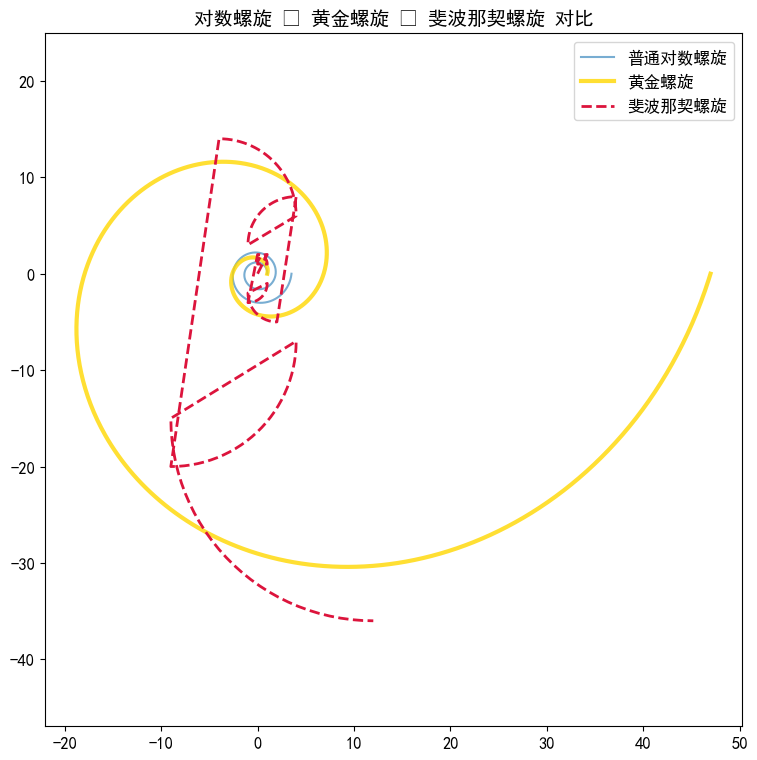

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ====================== 1. 准备参数 ======================
theta = np.linspace(0, 4 * np.pi, 1000)
a = 1
phi = (1 + np.sqrt(5)) / 2  # 黄金分割 1.618

# 普通对数螺旋
b1 = 0.1
r1 = a * np.exp(b1 * theta)
x1 = r1 * np.cos(theta)
y1 = r1 * np.sin(theta)

# 黄金螺旋（严格对数螺旋，每90度放大φ倍）
b2 = np.log(phi) / (np.pi / 2)
r2 = a * np.exp(b2 * theta)
x2 = r2 * np.cos(theta)
y2 = r2 * np.sin(theta)

# ====================== 2. 画斐波那契螺旋 ======================
def fib_list(n):
    fib = [1, 1]
    for i in range(2, n):
        fib.append(fib[-1] + fib[-2])
    return fib

fibs = fib_list(8)
x_fib, y_fib = [0], [0]
cx, cy = 0, 0
dx, dy = 1, 0

for f in fibs:
    nx = cx + f * dx
    ny = cy + f * dy

    # 画1/4圆弧
    arc_theta = np.linspace(0, np.pi/2, 30)
    acx = nx - dy * f
    acy = ny + dx * f
    arc_x = acx + dy * f * np.cos(arc_theta) - dx * f * np.sin(arc_theta)
    arc_y = acy + dy * f * np.sin(arc_theta) + dx * f * np.cos(arc_theta)

    x_fib.extend(arc_x)
    y_fib.extend(arc_y)

    dx, dy = -dy, dx
    cx, cy = nx, ny

# ====================== 3. 绘图对比 ======================
plt.figure(figsize=(9, 9))
# 全局配置
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.rcParams['font.size'] = 12                # 设置默认字体大小

plt.plot(x1, y1, linewidth=1.5, alpha=0.6, label='普通对数螺旋')
plt.plot(x2, y2, linewidth=3, alpha=0.8, color='gold', label='黄金螺旋')
plt.plot(x_fib, y_fib, linewidth=2, linestyle='--', color='crimson', label='斐波那契螺旋')

plt.axis('equal')
plt.title('对数螺旋 • 黄金螺旋 • 斐波那契螺旋 对比', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.show()